# Target 10m Model Experiments Overview

Обзор результатов staged hold-out перебора моделей для `target_log_return_10m`.

Локальные входные файлы скачаны из:

`s3://binance-data-downloader/dataset_target_10/model_experiments/latest/`

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 180)
plt.style.use("seaborn-v0_8-whitegrid")

RESULTS_DIR = Path("analysis/target_10_model_experiments/results/latest")
if not RESULTS_DIR.exists():
    RESULTS_DIR = Path("results/latest")

results = pd.read_parquet(RESULTS_DIR / "experiment_results.parquet")
stage_selection = pd.read_parquet(RESULTS_DIR / "stage_selection.parquet")
run_config = json.loads((RESULTS_DIR / "run_config.json").read_text(encoding="utf-8"))

results.shape, stage_selection.shape

((994, 42), (6, 9))

## Run Summary

In [2]:
summary_keys = [
    "run_id",
    "target",
    "direction_threshold",
    "train_rows",
    "test_rows",
    "n_jobs",
    "parallel_backend",
    "max_selected_per_stage",
]
pd.DataFrame(
    [{"field": key, "value": run_config.get(key)} for key in summary_keys]
)

,field,value
0,run_id,20260705_163911
1,target,target_log_return_10m
2,direction_threshold,0.0025
3,train_rows,2630700
4,test_rows,527040
5,n_jobs,24
6,parallel_backend,threading
7,max_selected_per_stage,6


In [3]:
stage_selection

,stage,stage_index,candidates,selected,selected_model_ids,n_jobs,parallel_backend,prep_time,prepared_features
0,stage_0_baseline,0,2,2,"[""stage_0_baseline_001_baseline_zero"", ""stage_0_baseline_002_baseline_mean""]",24,threading,2.275382,56
1,stage_1_ar,1,40,6,"[""stage_1_ar_003_lasso_alpha_1e_5"", ""stage_1_ar_004_lasso_alpha_1e_5"", ""stage_1_ar_005_lasso_alpha_1e_5"", ""stage_1_ar_004_huber"", ""stage_1_ar_005_huber"", ""stage_1_ar_003_ols""]",24,threading,2.275382,56
2,stage_2_price_volatility,2,144,6,"[""stage_2_price_volatility_006_lasso_alpha_1e_5"", ""stage_2_price_volatility_015_lasso_alpha_1e_5"", ""stage_2_price_volatility_007_lasso_alpha_1e_5"", ""stage_2_price_volatility_00...",24,threading,2.275382,56
3,stage_3_microstructure,3,320,6,"[""stage_3_microstructure_002_lasso_alpha_1e_5"", ""stage_3_microstructure_008_lasso_alpha_1e_5"", ""stage_3_microstructure_026_lasso_alpha_1e_5"", ""stage_3_microstructure_008_huber""...",24,threading,2.275382,56
4,stage_4_btc,4,200,6,"[""stage_4_btc_001_lasso_alpha_1e_5"", ""stage_4_btc_006_lasso_alpha_1e_5"", ""stage_4_btc_016_lasso_alpha_1e_5"", ""stage_4_btc_013_huber"", ""stage_4_btc_008_huber"", ""stage_4_btc_011_...",24,threading,2.275382,56
5,stage_5_calendar_sessions,5,288,6,"[""stage_5_calendar_sessions_006_lasso_alpha_1e_5"", ""stage_5_calendar_sessions_005_lasso_alpha_1e_5"", ""stage_5_calendar_sessions_004_lasso_alpha_1e_5"", ""stage_5_calendar_session...",24,threading,2.275382,56


## Global Top Models

In [4]:
display_cols = [
    "model_id",
    "stage",
    "model_family",
    "feature_set",
    "n_features",
    "MAE",
    "RMSE",
    "Direction_Accuracy",
    "Direction_Accuracy_025",
    "DA_025_coverage",
    "OOS_R2",
    "Pearson_corr",
]

top_a = results.sort_values(
    ["MAE", "RMSE", "n_features", "simplicity_rank", "model_id"],
    ascending=[True, True, True, True, True],
).head(15)

top_b = results.sort_values(
    ["Direction_Accuracy_025", "n_features", "simplicity_rank", "model_id"],
    ascending=[False, True, True, True],
    na_position="last",
).head(15)

top_a[display_cols]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr
750,stage_5_calendar_sessions_006_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+all_calendar_sessions,21,0.002704,0.005219,0.514451,0.514944,0.385474,0.011279,0.137813
742,stage_5_calendar_sessions_005_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+day_sessions,19,0.002704,0.005219,0.514451,0.514944,0.385474,0.011279,0.137813
734,stage_5_calendar_sessions_004_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+time_sessions,18,0.002704,0.005219,0.514445,0.514973,0.385474,0.011278,0.137807
726,stage_5_calendar_sessions_003_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+sessions,16,0.002704,0.005219,0.514445,0.514973,0.385474,0.011278,0.137807
774,stage_5_calendar_sessions_009_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_returns_only+sessions,29,0.002704,0.005220,0.514279,0.514698,0.385474,0.010931,0.133331
790,stage_5_calendar_sessions_011_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_returns_only+day_sessions,32,0.002704,0.005220,0.514279,0.514698,0.385474,0.010931,0.133331
782,stage_5_calendar_sessions_010_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_returns_only+time_sessions,31,0.002704,0.005220,0.514279,0.514698,0.385474,0.010931,0.133331
798,stage_5_calendar_sessions_012_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_returns_only+all_calendar_sessions,34,0.002704,0.005220,0.514279,0.514698,0.385474,0.010931,0.133331
990,stage_5_calendar_sessions_036_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility+trades_only+btc_returns_only+all_calendar_sessions,22,0.002704,0.005219,0.514340,0.514786,0.385474,0.011274,0.137584
982,stage_5_calendar_sessions_035_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility+trades_only+btc_returns_only+day_sessions,20,0.002704,0.005219,0.514340,0.514786,0.385474,0.011274,0.137584


In [5]:
top_b[display_cols]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr
945,stage_5_calendar_sessions_030_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+all_calendar_sessions,35,0.002705,0.005217,0.516217,0.516425,0.385474,0.012067,0.114466
809,stage_5_calendar_sessions_013_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_efficiency_only+time_of_day,28,0.002705,0.005217,0.516147,0.516411,0.385474,0.011897,0.113506
833,stage_5_calendar_sessions_016_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_efficiency_only+time_sessions,30,0.002705,0.005217,0.516525,0.516401,0.385474,0.012070,0.114391
849,stage_5_calendar_sessions_018_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_efficiency_only+all_calendar_sessions,33,0.002705,0.005217,0.516371,0.516332,0.385474,0.011997,0.114099
889,stage_5_calendar_sessions_023_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_returns_only+day_sessions,34,0.002705,0.005216,0.516248,0.516327,0.385474,0.012246,0.115517
929,stage_5_calendar_sessions_028_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+time_sessions,32,0.002705,0.005217,0.516476,0.516317,0.385474,0.012034,0.114382
801,stage_5_calendar_sessions_012_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility+all_microstructure+btc_returns_only+all_calendar_sessions,34,0.002705,0.005217,0.516159,0.516273,0.385474,0.012089,0.114695
737,stage_5_calendar_sessions_004_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+time_sessions,18,0.002705,0.005217,0.516463,0.516253,0.385474,0.012082,0.114025
897,stage_5_calendar_sessions_024_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_returns_only+all_calendar_sessions,36,0.002705,0.005217,0.516122,0.516219,0.385474,0.012166,0.115130
977,stage_5_calendar_sessions_034_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_10+trend_volatility+trades_only+btc_returns_only+time_sessions,19,0.002705,0.005217,0.516461,0.516214,0.385474,0.012080,0.113995


## Best Model By Stage

In [6]:
best_mae_by_stage = (
    results.sort_values(["stage", "MAE", "RMSE", "n_features", "simplicity_rank"])
    .groupby("stage", as_index=False)
    .first()
)

best_da_by_stage = (
    results.sort_values(
        ["stage", "Direction_Accuracy_025", "n_features", "simplicity_rank"],
        ascending=[True, False, True, True],
        na_position="last",
    )
    .groupby("stage", as_index=False)
    .first()
)

best_mae_by_stage[display_cols]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr
0,stage_0_baseline_001_baseline_zero,stage_0_baseline,baseline_zero,baseline_zero,0,0.002707,0.005249,0.494219,0.000000,0.385474,0.000000,NaN
1,stage_1_ar_003_lasso_alpha_1e_5,stage_1_ar,lasso_alpha_1e_5,baseline_zero+ar_5,4,0.002706,0.005248,0.507236,0.508634,0.385474,0.000358,0.020965
2,stage_2_price_volatility_006_lasso_alpha_1e_5,stage_2_price_volatility,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility,10,0.002704,0.005220,0.514038,0.514068,0.385474,0.010717,0.130613
3,stage_3_microstructure_002_lasso_alpha_1e_5,stage_3_microstructure,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only,12,0.002704,0.005219,0.514435,0.514772,0.385474,0.011261,0.137301
4,stage_4_btc_001_lasso_alpha_1e_5,stage_4_btc,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only,14,0.002704,0.005219,0.514318,0.514649,0.385474,0.011184,0.136909
5,stage_5_calendar_sessions_006_lasso_alpha_1e_5,stage_5_calendar_sessions,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility+trades_only+btc_returns_only+all_calendar_sessions,21,0.002704,0.005219,0.514451,0.514944,0.385474,0.011279,0.137813


In [7]:
best_da_by_stage[display_cols]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr
0,stage_0_baseline_002_baseline_mean,stage_0_baseline,baseline_mean,baseline_mean,0,0.002707,0.005249,0.494219,0.494339,0.385474,-0.000022,NaN
1,stage_1_ar_004_huber,stage_1_ar,huber,baseline_zero+ar_10,5,0.002707,0.005248,0.508241,0.510883,0.385474,0.000324,0.024483
2,stage_2_price_volatility_009_huber,stage_2_price_volatility,huber,baseline_zero+ar_5+all_price_volatility,29,0.002705,0.005213,0.514784,0.515795,0.385474,0.013534,0.120097
3,stage_3_microstructure_008_huber,stage_3_microstructure,huber,baseline_zero+ar_5+trend_volatility+all_microstructure,25,0.002705,0.005217,0.515972,0.516002,0.385474,0.012215,0.115208
4,stage_4_btc_013_huber,stage_4_btc,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_efficiency_only,28,0.002705,0.005218,0.515900,0.516120,0.385474,0.011542,0.111591
5,stage_5_calendar_sessions_030_huber,stage_5_calendar_sessions,huber,baseline_zero+ar_5+trend_volatility_efficiency+all_microstructure+btc_efficiency_only+all_calendar_sessions,35,0.002705,0.005217,0.516217,0.516425,0.385474,0.012067,0.114466


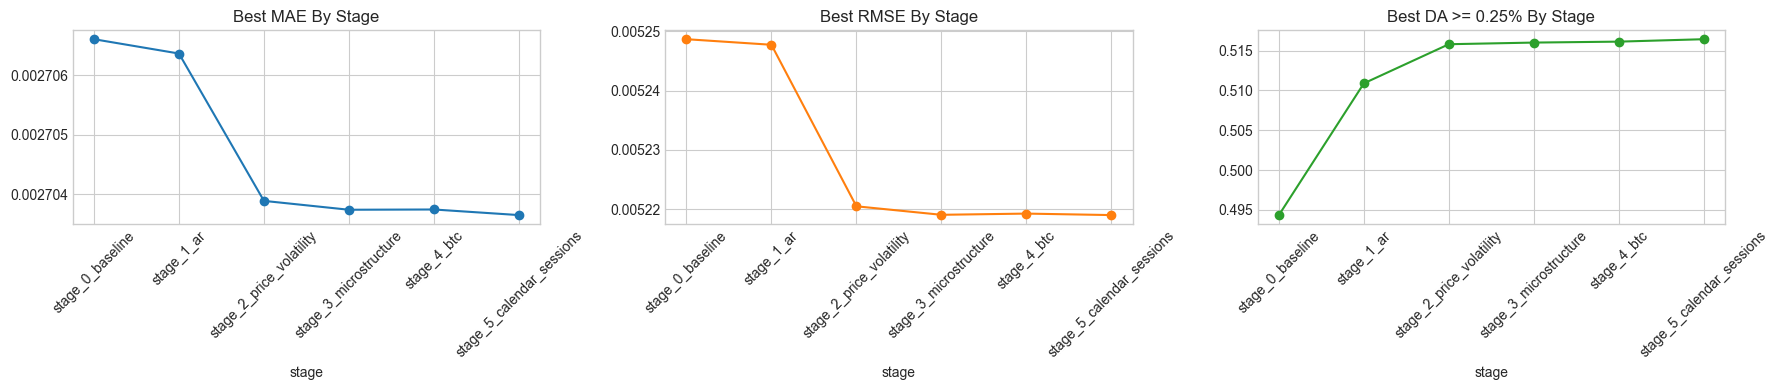

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

best_mae_by_stage.plot(x="stage", y="MAE", marker="o", ax=axes[0], legend=False)
axes[0].set_title("Best MAE By Stage")
axes[0].tick_params(axis="x", rotation=45)

best_mae_by_stage.plot(x="stage", y="RMSE", marker="o", ax=axes[1], legend=False, color="tab:orange")
axes[1].set_title("Best RMSE By Stage")
axes[1].tick_params(axis="x", rotation=45)

best_da_by_stage.plot(x="stage", y="Direction_Accuracy_025", marker="o", ax=axes[2], legend=False, color="tab:green")
axes[2].set_title("Best DA >= 0.25% By Stage")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()

## Added Block Informativeness

In [9]:
block_summary = (
    results.loc[results["stage"].ne("stage_0_baseline")]
    .groupby(["stage", "added_block"], as_index=False)
    .agg(
        models=("model_id", "count"),
        best_MAE=("MAE", "min"),
        median_MAE=("MAE", "median"),
        best_RMSE=("RMSE", "min"),
        best_DA_025=("Direction_Accuracy_025", "max"),
        median_DA_025=("Direction_Accuracy_025", "median"),
        best_OOS_R2=("OOS_R2", "max"),
        median_delta_MAE=("delta_MAE", "median"),
        median_delta_RMSE=("delta_RMSE", "median"),
        median_delta_DA_025=("delta_DA_025", "median"),
    )
    .sort_values(["stage", "best_MAE", "best_RMSE"])
)

block_summary

,stage,added_block,models,best_MAE,median_MAE,best_RMSE,best_DA_025,median_DA_025,best_OOS_R2,median_delta_MAE,median_delta_RMSE,median_delta_DA_025
3,stage_1_ar,ar_5,8,0.002706,0.002706,0.005248,0.509116,0.509077,0.000375,-1.775819e-07,-9.620347e-07,0.509077
1,stage_1_ar,ar_10,8,0.002706,0.002706,0.005248,0.510883,0.509018,0.000365,-1.661461e-07,-9.479931e-07,0.509018
4,stage_1_ar,ar_all,8,0.002706,0.002706,0.005248,0.510883,0.509018,0.000365,-1.661461e-07,-9.479931e-07,0.509018
2,stage_1_ar,ar_3,8,0.002707,0.002707,0.005249,0.508437,0.508196,-0.000065,-4.771908e-08,3.460786e-07,0.508196
0,stage_1_ar,ar_1,8,0.002707,0.002707,0.005249,0.505990,0.505934,-0.000065,3.077036e-07,2.354712e-06,0.505934
11,stage_2_price_volatility,trend_volatility,16,0.002704,0.002705,0.005218,0.514905,0.513876,0.011631,-1.554786e-06,-2.959431e-05,0.004789
12,stage_2_price_volatility,trend_volatility_efficiency,16,0.002704,0.002705,0.005217,0.514895,0.513844,0.012170,-1.718173e-06,-3.039044e-05,0.004937
10,stage_2_price_volatility,trend,16,0.002704,0.002704,0.005234,0.514594,0.513999,0.005409,-2.144024e-06,-1.020546e-05,0.005282
6,stage_2_price_volatility,all_price_volatility,16,0.002704,0.002708,0.005208,0.515795,0.506771,0.015345,1.754410e-06,-3.824124e-05,-0.001991
9,stage_2_price_volatility,price_deviation,16,0.002705,0.002707,0.005248,0.514058,0.505208,0.000415,4.442328e-07,-5.285076e-08,-0.003460


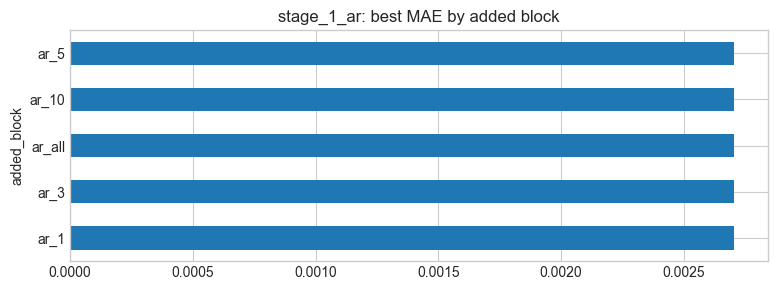

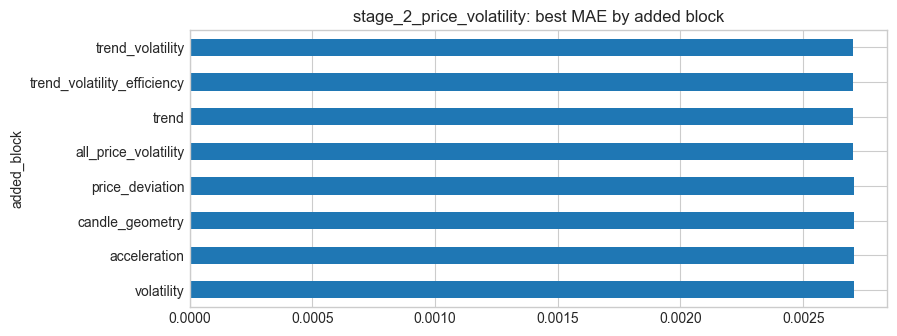

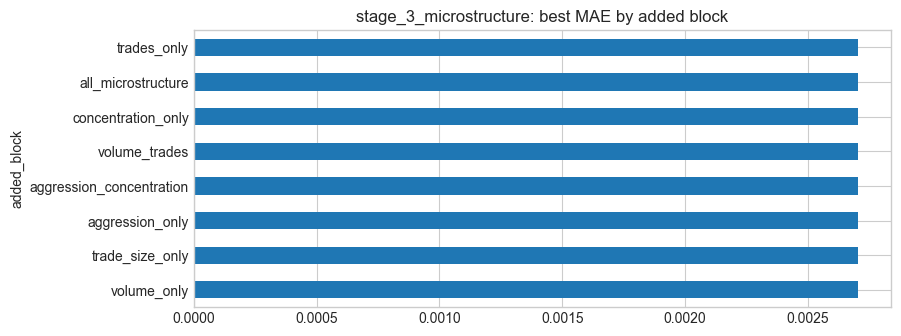

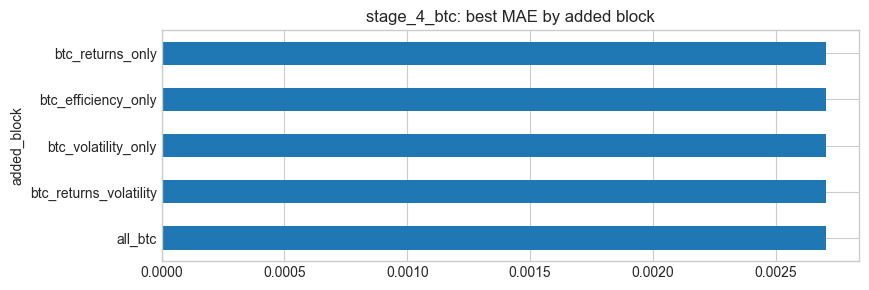

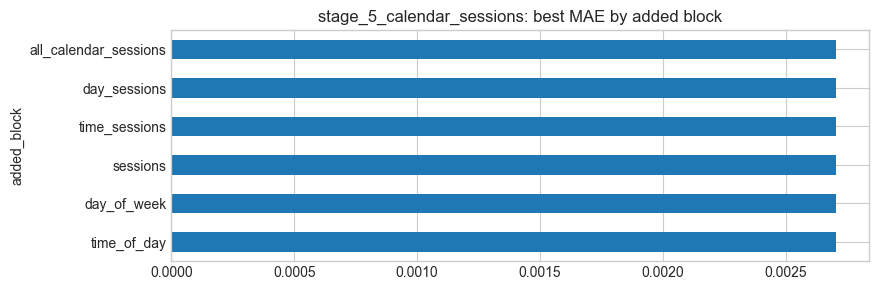

In [10]:
for stage, frame in block_summary.groupby("stage"):
    top_blocks = frame.sort_values("best_MAE").head(8)
    ax = top_blocks.plot.barh(
        x="added_block",
        y="best_MAE",
        figsize=(9, max(3, len(top_blocks) * 0.45)),
        legend=False,
        title=f"{stage}: best MAE by added block",
    )
    ax.invert_yaxis()
    plt.show()

## Selected Models By Stage

In [11]:
selected = results.loc[results["selected_for_next_stage"]].copy()
selected.sort_values(["stage", "rank_A", "rank_B"])[display_cols + ["rank_A", "rank_B", "selection_reason", "previous_model", "added_block"]]

,model_id,stage,model_family,feature_set,n_features,MAE,RMSE,Direction_Accuracy,Direction_Accuracy_025,DA_025_coverage,OOS_R2,Pearson_corr,rank_A,rank_B,selection_reason,previous_model,added_block
0,stage_0_baseline_001_baseline_zero,stage_0_baseline,baseline_zero,baseline_zero,0,0.002707,0.005249,NaN,0.000000,0.385474,0.000000,NaN,1,2,top_A_top_B,NaN,baseline_zero
1,stage_0_baseline_002_baseline_mean,stage_0_baseline,baseline_mean,baseline_mean,0,0.002707,0.005249,0.494219,0.494339,0.385474,-0.000022,NaN,2,1,top_A_top_B,NaN,baseline_mean
22,stage_1_ar_003_lasso_alpha_1e_5,stage_1_ar,lasso_alpha_1e_5,baseline_zero+ar_5,4,0.002706,0.005248,0.507236,0.508634,0.385474,0.000358,0.020965,1,16,top_A,stage_0_baseline_001_baseline_zero,ar_5
30,stage_1_ar_004_lasso_alpha_1e_5,stage_1_ar,lasso_alpha_1e_5,baseline_zero+ar_10,5,0.002706,0.005248,0.507236,0.508634,0.385474,0.000358,0.020965,2,17,top_A,stage_0_baseline_001_baseline_zero,ar_10
38,stage_1_ar_005_lasso_alpha_1e_5,stage_1_ar,lasso_alpha_1e_5,baseline_zero+ar_all,5,0.002706,0.005248,0.507236,0.508634,0.385474,0.000358,0.020965,3,18,top_A,stage_0_baseline_001_baseline_zero,ar_all
18,stage_1_ar_003_ols,stage_1_ar,ols,baseline_zero+ar_5,4,0.002706,0.005248,0.507641,0.509116,0.385474,0.000375,0.022370,7,3,top_B,stage_0_baseline_001_baseline_zero,ar_5
33,stage_1_ar_004_huber,stage_1_ar,huber,baseline_zero+ar_10,5,0.002707,0.005248,0.508241,0.510883,0.385474,0.000324,0.024483,25,1,top_B,stage_0_baseline_001_baseline_zero,ar_10
41,stage_1_ar_005_huber,stage_1_ar,huber,baseline_zero+ar_all,5,0.002707,0.005248,0.508241,0.510883,0.385474,0.000324,0.024483,26,2,top_B,stage_0_baseline_001_baseline_zero,ar_all
86,stage_2_price_volatility_006_lasso_alpha_1e_5,stage_2_price_volatility,lasso_alpha_1e_5,baseline_zero+ar_5+trend_volatility,10,0.002704,0.005220,0.514038,0.514068,0.385474,0.010717,0.130613,1,20,top_A,stage_1_ar_003_ols,trend_volatility
158,stage_2_price_volatility_015_lasso_alpha_1e_5,stage_2_price_volatility,lasso_alpha_1e_5,baseline_zero+ar_10+trend_volatility,11,0.002704,0.005220,0.513825,0.513428,0.385474,0.010716,0.130449,2,54,top_A,stage_1_ar_004_lasso_alpha_1e_5,trend_volatility


## Model Family Diagnostics

In [12]:
family_summary = (
    results.groupby(["stage", "model_family"], as_index=False)
    .agg(
        models=("model_id", "count"),
        best_MAE=("MAE", "min"),
        median_MAE=("MAE", "median"),
        best_DA_025=("Direction_Accuracy_025", "max"),
        median_DA_025=("Direction_Accuracy_025", "median"),
        best_OOS_R2=("OOS_R2", "max"),
        total_fit_time=("fit_time", "sum"),
    )
    .sort_values(["stage", "best_MAE"])
)

family_summary

,stage,model_family,models,best_MAE,median_MAE,best_DA_025,median_DA_025,best_OOS_R2,total_fit_time
1,stage_0_baseline,baseline_zero,1,0.002707,0.002707,0.000000,0.000000,0.000000,0.000001
0,stage_0_baseline,baseline_mean,1,0.002707,0.002707,0.494339,0.494339,-0.000022,0.000690
5,stage_1_ar,lasso_alpha_1e_5,5,0.002706,0.002706,0.508634,0.508634,0.000358,2.761176
9,stage_1_ar,ridge_alpha_10,5,0.002706,0.002706,0.509116,0.509018,0.000375,2.501939
8,stage_1_ar,ridge_alpha_1,5,0.002706,0.002706,0.509116,0.509018,0.000375,2.394722
7,stage_1_ar,ridge_alpha_0_1,5,0.002706,0.002706,0.509116,0.509018,0.000375,2.399623
6,stage_1_ar,ols,5,0.002706,0.002706,0.509116,0.509018,0.000375,2.918789
2,stage_1_ar,elasticnet_alpha_1e_4_l1_0_5,5,0.002707,0.002707,0.506926,0.506926,-0.000034,3.222073
3,stage_1_ar,huber,5,0.002707,0.002707,0.510883,0.509037,0.000324,15.280554
4,stage_1_ar,lasso_alpha_1e_4,5,0.002707,0.002707,0.497312,0.497312,-0.000065,2.528736


## Notes For Interpretation

- `Direction_Accuracy_025` считается только на наблюдениях, где `abs(y_true) >= 0.25%`.
- `OOS_R2` считается относительно zero baseline.
- `delta_*` считается относительно `previous_model`, то есть показывает локальный эффект добавленного блока внутри цепочки отбора.
- Финальные победители по MAE и directional accuracy могут отличаться: это ожидаемо для задачи точечной доходности.